<a href="https://www.kaggle.com/code/hanigaouaou/netflix-content-clustering?scriptVersionId=300898328" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<a href="https://www.kaggle.com/code/hanigaouaou/netflix-content-clustering?scriptVersionId=226196796" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Netflix Content Clustering
## The Effect of Imputation Strategy on Unsupervised Learning

Most clustering tutorials treat missing data as an afterthought. This notebook takes a different stance: **missing data handling is a modelling decision that directly shapes what structure the algorithm finds.**

We apply K-Means clustering to the Netflix Movies and TV Shows dataset and deliberately test three imputation strategies — listwise deletion, mean/mode imputation, and custom placeholder imputation — measuring how each affects cluster quality via the silhouette score. The dataset is well-suited for this investigation: it contains meaningful missingness patterns across several columns (director, cast, country, rating), and the clustering task is sensitive to the quality of exactly those features.

**Pipeline:** data audit → feature selection → three-variant imputation → feature engineering (TF-IDF genre vectorisation, composite production scores) → K-Means → PCA visualisation → comparative evaluation.

## Mathematical Foundations

### K-Means Clustering

K-Means partitions $n$ observations into $k$ clusters by minimising total within-cluster variance (inertia):

$$J = \sum_{i=1}^{k} \sum_{x \in C_i} \|x - \mu_i\|_2^2$$

where $C_i$ is the $i$-th cluster and $\mu_i$ its centroid. The algorithm alternates between assignment (each point goes to its nearest centroid) and update (centroids recomputed as cluster means) until convergence. K-Means is a **hard assignment** algorithm — computationally efficient but sensitive to initialisation and feature scale.

### Silhouette Score

The silhouette coefficient quantifies how well each point fits its assigned cluster relative to the nearest alternative:

$$s(i) = \frac{b(i) - a(i)}{\max(a(i),\ b(i))}$$

where $a(i)$ is the mean intra-cluster distance (cohesion) and $b(i)$ is the mean distance to the nearest neighbouring cluster (separation). $s(i) \in [-1, 1]$: values near 1 indicate well-separated clusters; values near 0 indicate boundary ambiguity. The mean silhouette across all points is the primary comparison metric.

### TF-IDF for Genre Vectorisation

The `listed_in` column contains comma-separated genre strings. TF-IDF converts these into a numerical feature space:

$$\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \log\left(\frac{N}{df(t)}\right)$$

where $N$ is the total number of titles and $df(t)$ is the number of titles containing genre $t$. Genres common to all titles receive low weight; discriminative genres receive higher weight. This produces a sparse matrix encoding genre similarity between titles.

### PCA for Visualisation

After clustering in the high-dimensional feature space, PCA projects down to 2D for visual inspection. PCA finds the orthogonal directions of maximum variance via the eigenvectors of the covariance matrix $\Sigma = \frac{1}{n}X^TX$, providing the most faithful low-dimensional view of the cluster structure.

## 1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("/kaggle/input/netflix-shows/netflix_titles.csv") # Getting the DataFrame from a csv file

# Display basic information
print("Dataset Overview:")
print("-" * 50)
print("\nDataset Shape:", df.shape)
print("\nColumns in the dataset:")
print(*df.columns.tolist(), sep=' |')
print("\nData Summary:")
df.info()
print("\nA Look into the dataset:")
df.tail(5)


Dataset Overview:
--------------------------------------------------

Dataset Shape: (8807, 12)

Columns in the dataset:
show_id |type |title |director |cast |country |date_added |release_year |rating |duration |listed_in |description

Data Summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB

A

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


## 2. Data Audit and Feature Selection

### 2.1 Completeness Assessment

A structured audit precedes any modelling decision. We examine missingness both numerically and visually. The heatmap reveals whether missing values are concentrated in specific rows (systematic pattern) or distributed across the dataset (consistent with MCAR — Missing Completely At Random). This distinction matters: systematic missingness implies that dropping rows introduces selection bias, while random missingness makes deletion safer.

Missing Value Report:
            Missing Values  Percent Missing
director              2634            29.91
cast                   825             9.37
country                831             9.44
date_added              10             0.11
rating                   4             0.05
duration                 3             0.03


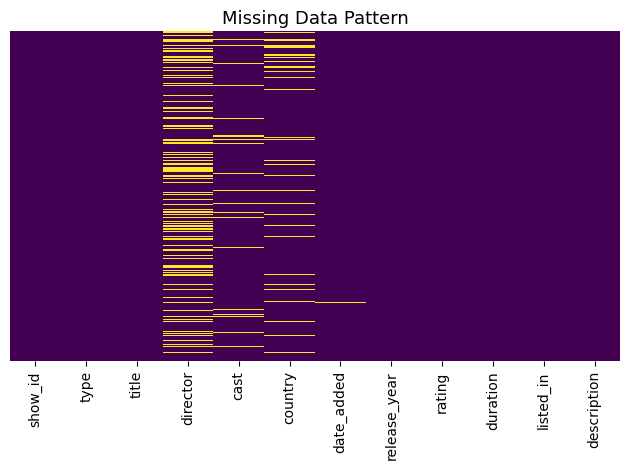

Duplicate rows: 0
Dataset shape: (8807, 12)


In [2]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

missing_values = df.isnull().sum()[df.isnull().sum() > 0]
missing_percent = (missing_values / len(df)) * 100

missing_data = pd.DataFrame({
    'Missing Values': missing_values,
    'Percent Missing': missing_percent.round(2)
})
print('Missing Value Report:')
print(missing_data)

sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Data Pattern', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Duplicate rows: {df.duplicated().sum()}')
print(f'Dataset shape: {df.shape}')

### 2.2 Feature Selection

Not all columns carry clustering-relevant information. `description` is unstructured long-form text requiring heavy NLP preprocessing with limited payoff for production-style clustering. `date_added` reflects catalogue logistics rather than content properties. `show_id` is a row identifier. All three are excluded.

The retained feature set — `type`, `release_year`, `rating`, `duration`, `listed_in`, `director`, `cast`, `country` — covers temporal, categorical, and textual signals across production and content dimensions.

In [3]:
selected_features = ['type', 'release_year', 'rating', 'duration',
                     'listed_in', 'director', 'cast', 'country']

df_relevant = df[selected_features].copy()
print(f'Reduced dataset: {df_relevant.shape}')
df_relevant.info()

Reduced dataset: (8807, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   type          8807 non-null   object
 1   release_year  8807 non-null   int64 
 2   rating        8803 non-null   object
 3   duration      8804 non-null   object
 4   listed_in     8807 non-null   object
 5   director      6173 non-null   object
 6   cast          7982 non-null   object
 7   country       7976 non-null   object
dtypes: int64(1), object(7)
memory usage: 550.6+ KB


## 3. Imputation Strategies and Dataset Variants

The central experiment of this notebook is a controlled comparison of three missing data strategies. Each produces a distinct dataset variant carried through the full pipeline independently, so that any differences in clustering outcomes are attributable solely to imputation choice.

**Variant 1 — Listwise Deletion (`dropped`):** Rows containing any missing value are removed. This preserves data integrity at the cost of sample size (~30% of records lost). The implicit assumption is that missingness is ignorable (MCAR or MAR). This assumption may not hold if, for example, director information is systematically absent for lower-profile productions.

**Variant 2 — Mean/Mode Imputation (`mean_mode`):** Numerical features are filled with the column median; categorical features with the mode. This preserves the full sample but artificially concentrates mass at the imputed values, reducing variance and potentially collapsing natural sub-groups.

**Variant 3 — Custom Placeholder Imputation (`custom`):** Missing values are replaced with semantically explicit placeholders (`'Unknown'` for text, `-1` for numeric). This treats missingness as an informative signal — the `'Unknown'` category may cluster together, potentially corresponding to a real pattern (e.g. indie productions with no credited director). The risk is that placeholder clusters form around the artefact rather than genuine content similarity.

In [4]:
# Processing the duration column alone since the movies and tv shows each has a different number systems
# The following function will be used later in the 2nd dataset variant (filled dataset)
def process_duration(df):
    """
    Process and normalize the duration column for Netflix content, handling movies (minutes) 
    and TV shows (seasons) separately.
    
    Args:
        df (pd.DataFrame): DataFrame containing 'type' and 'duration' columns
    
    Returns:
        pd.DataFrame: DataFrame with processed and normalized duration values
    """
    # Ensure required columns are present
    required_columns = ['type', 'duration']
    if not all(col in df.columns for col in required_columns):
        raise ValueError(f"DataFrame must contain columns: {required_columns}")

    # Create a copy to avoid modifying the original DataFrame
    df_relevant = df.copy()

    # Separate Movies and TV Shows
    movies = df_relevant[df_relevant["type"] == "Movie"].copy()
    tv_shows = df_relevant[df_relevant["type"] == "TV Show"].copy()

    # Process Movie durations
    try:
        movies["duration"] = movies["duration"].str.extract("(\d+)").astype(float)
    except Exception as e:
        print(f"Error processing movie durations: {e}")
        movies["duration"] = np.nan

    # Process TV Show durations
    try:
        tv_shows["duration"] = tv_shows["duration"].str.extract("(\d+)").astype(float)
    except Exception as e:
        print(f"Error processing TV show durations: {e}")
        tv_shows["duration"] = np.nan

    # Define and fit imputers
    imputer_median_movies = SimpleImputer(strategy="median")
    imputer_median_tv_shows = SimpleImputer(strategy="median")

    # Impute missing values
    movies.loc[:, "duration"] = imputer_median_movies.fit_transform(movies[["duration"]])
    tv_shows.loc[:, "duration"] = imputer_median_tv_shows.fit_transform(tv_shows[["duration"]])

    # Combine datasets and sort by original index
    df_processed = pd.concat([movies, tv_shows], axis=0)
    df_processed = df_processed.sort_index()

    return df_processed

In [5]:
# 4. Dealing with missing values:

# 4.1. Identify columns with missing values in the reduced dataset
missing_columns = df_relevant.columns[df_relevant.isnull().any()]
print(f"Columns with missing values: {missing_columns.tolist()}")
print("-" * 50)

# 4.2. Create data variants with different imputation strategies (dropped, mean_mode, custom)
dataset_variants = {}

# Variant 1:  ------------------------------------------------------------------------------------
# Drop rows with missing values

dataset_variants['dropped'] = df_relevant.dropna()

# Variant 2: -------------------------------------------------------------------------------------
# Fill missing values with the mode (for categorical) and median (for numerical)


# Dividing the missing_columns into categorical and numerical
categorical_features = ["rating", "director", "cast", "country"]
numerical_features = ["duration"]

df_processed = process_duration(df_relevant) # Defined earlier...

imputer_mode = SimpleImputer(strategy="most_frequent") # For categoricals
# A median imputer is already used in the process_duration function

# Apply imputer
df_mode_imputed = df_processed.copy()
df_mode_imputed[categorical_features] = imputer_mode.fit_transform(df_mode_imputed[categorical_features])
dataset_variants['mean_mode'] = df_mode_imputed


# Variant 3: -------------------------------------------------------------------------------------
# Fill missing values with a placeholder (e.g., "Unknown" or -1)

dataset_variants['custom'] = df_relevant.fillna({
    "rating": "Unknown",
    "director": "Unknown",
    "cast": "Unknown",
    "country": "Unknown",
    "duration": '-1'
})

# From now our datasets will be referred to as the dataset_variants
#-------------------------------------------------------------------------------------------------

# 3. Data Type Conversions, Transformations and Cleaning
# Since we have 3 different datasets, a function for each step is better to avoid repetition


def preprocess_dataset(df):
    df_processed = df.copy()
    
    # Convert release_year to numeric
    df_processed['release_year'] = df_processed['release_year'].astype("int")

    # Convert duration to numeric for 'dropped' and 'custom' dataset variants:
    if not pd.api.types.is_numeric_dtype(df_processed['duration']):
        df_processed['duration'] = df_processed['duration'].str.extract("(\d+)").astype(float)
    
    # Convert to categorical dtype for better memory usage and more versatility
    pd.Categorical(df, categories=["type", "rating", "listed_in", "director", "cast", "country"])
    
    return df_processed


# 4. Data Splitting: 
def split_dataset(df, test_size=0.2, random_state=42):
    """
    Split dataset into training and validation sets
    Stratify by 'type' to maintain distribution of movies/shows
    """
    train_df, val_df = train_test_split(
        df,
        test_size=test_size,
        random_state=random_state,
        stratify=df['type']
    )
    return train_df, val_df


# Process and split each variant
processed_variants = {}
split_variants = {}

for name, dataset in dataset_variants.items():
    # Process
    processed_variants[name] = preprocess_dataset(dataset)
    # Split
    train, val = split_dataset(processed_variants[name])
    split_variants[name] = {'train': train, 'val': val}

# 6. Print Summary Statistics for each variant
print("\n3. VARIANT COMPARISON:")
print("-" * 50)
for name, data in processed_variants.items():
    print(f"\nVariant: {name}")
    print(f"Missing values:")
    print(data[missing_columns].isnull().sum())
    print("\nBasic statistics:")
    print(data.describe().round(2))
    print("\nSplit sizes:")
    print(f"Training set: {len(split_variants[name]['train'])} records")
    print(f"Validation set: {len(split_variants[name]['val'])} records")
print(processed_variants["custom"]["duration"][processed_variants["custom"]["duration"].isnull()])
 

Columns with missing values: ['rating', 'duration', 'director', 'cast', 'country']
--------------------------------------------------

3. VARIANT COMPARISON:
--------------------------------------------------

Variant: dropped
Missing values:
rating      0
duration    0
director    0
cast        0
country     0
dtype: int64

Basic statistics:
       release_year  duration
count       5332.00   5332.00
mean        2012.74     99.92
std            9.63     30.46
min         1942.00      1.00
25%         2011.00     88.00
50%         2016.00    100.00
75%         2018.00    116.00
max         2021.00    253.00

Split sizes:
Training set: 4265 records
Validation set: 1067 records

Variant: mean_mode
Missing values:
rating      0
duration    0
director    0
cast        0
country     0
dtype: int64

Basic statistics:
       release_year  duration
count       8807.00   8807.00
mean        2014.18     69.86
std            8.82     50.81
min         1925.00      1.00
25%         2013.00      2.

## 4. Feature Engineering

Raw features are not directly suitable for K-Means. We engineer a numerical feature set capturing the primary dimensions of content variation: temporal positioning, genre composition, production scale, cast characteristics, and audience targeting. The `engineer_features` function is applied identically to all three variants — differences in downstream clustering are due to imputation, not feature construction.

Key engineering decisions:

- **TF-IDF on genres**: converts the comma-separated `listed_in` field into a sparse numerical matrix where genre co-occurrence patterns are encoded as feature similarity
- **`cast_diversity`**: ratio of unique cast members to total cast count — distinguishes ensemble productions from single-star vehicles
- **`director_popularity`**: frequency of each director's appearance in the dataset, normalised to [0,1] — a proxy for prominence that is particularly sensitive to the imputation strategy applied to the director column
- **`duration_normalized` and `log_duration`**: two complementary transformations; Min-Max scaling for K-Means distance sensitivity, log transformation to reduce the influence of outliers in the duration distribution

In [6]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer

def engineer_features(df):
    df_eng = df.copy()
    scaler = MinMaxScaler()
    le = LabelEncoder()

    # Temporal
    current_year = pd.Timestamp.now().year
    df_eng['content_age'] = current_year - df_eng['release_year']
    df_eng['decade'] = (df_eng['release_year'] // 10) * 10
    df_eng['content_age'].fillna(df_eng['content_age'].median(), inplace=True)
    df_eng['decade'].fillna(0, inplace=True)

    # Genre
    df_eng['primary_genre'] = df_eng['listed_in'].str.split(',').str[0]
    df_eng['multi_genre'] = df_eng['listed_in'].str.contains(',').astype(int)
    df_eng['genre_count'] = df_eng['listed_in'].str.count(',') + 1
    tfidf = TfidfVectorizer(token_pattern=r'[^,\s]+')
    genre_tfidf = tfidf.fit_transform(df_eng['listed_in'])
    genre_features = pd.DataFrame(
        genre_tfidf.toarray(),
        columns=[f'genre_feat_{i}' for i in range(genre_tfidf.shape[1])]
    )
    df_eng = pd.concat([df_eng.reset_index(drop=True), genre_features.reset_index(drop=True)], axis=1)

    # Cast
    df_eng['cast_size'] = df_eng['cast'].str.count(',') + 1
    df_eng['cast_diversity'] = df_eng['cast'].apply(
        lambda x: len(set(x.split(','))) / max(len(x.split(',')), 1)
    )

    # Country / production scope
    df_eng['production_countries'] = df_eng['country'].str.count(',') + 1
    df_eng['is_international'] = (df_eng['country'].str.count(',') > 0).astype(int)

    # Rating groups
    rating_groups = {
        'Kids':      ['TV-Y', 'TV-Y7', 'TV-Y7-FV', 'G'],
        'Teen':      ['TV-PG', 'TV-G', 'PG', 'TV-14', 'PG-13'],
        'Adult':     ['TV-MA', 'R', 'NC-17'],
        'Not Rated': ['NR', 'UR', 'Unknown']
    }
    rating_map = {v: k for k, lst in rating_groups.items() for v in lst}
    df_eng['rating_category'] = df_eng['rating'].map(rating_map)

    # Duration
    df_eng['duration_normalized'] = scaler.fit_transform(df_eng[['duration']])
    df_eng['log_duration'] = np.log1p(df_eng['duration'].clip(lower=0))

    # Encode type and rating
    df_eng['type'] = le.fit_transform(df_eng['type'])
    df_eng['rating_score'] = le.fit_transform(df_eng['rating_category'])

    # Director
    director_counts = df['director'].value_counts()
    df_eng['director_popularity'] = df_eng['director'].map(director_counts)
    df_eng['director_popularity'] = scaler.fit_transform(df_eng[['director_popularity']])
    df_eng['director_count'] = df_eng['director'].str.count(',') + 1

    return df_eng


for name, dataset in processed_variants.items():
    processed_variants[name] = engineer_features(dataset)
    print(f'  {name}: {processed_variants[name].shape}')

  dropped: (5332, 66)
  mean_mode: (8807, 66)
  custom: (8807, 66)


### 4.1 Composite Production Scores

Two composite scores aggregate multiple features into summary variables:

- **`production_scale`**: weighted combination of international scope (0.4), cast size (0.3), and production country count (0.3) — a proxy for budget and reach
- **`content_complexity`**: computed separately for movies (incorporating duration) and TV shows (season-count-based), combining genre breadth and cast size

The weights are domain-informed rather than learned. In a more rigorous study, these could be replaced by learned representations (e.g. a factorisation model), but for this analysis they serve as interpretable aggregations.


Processing dropped variant:


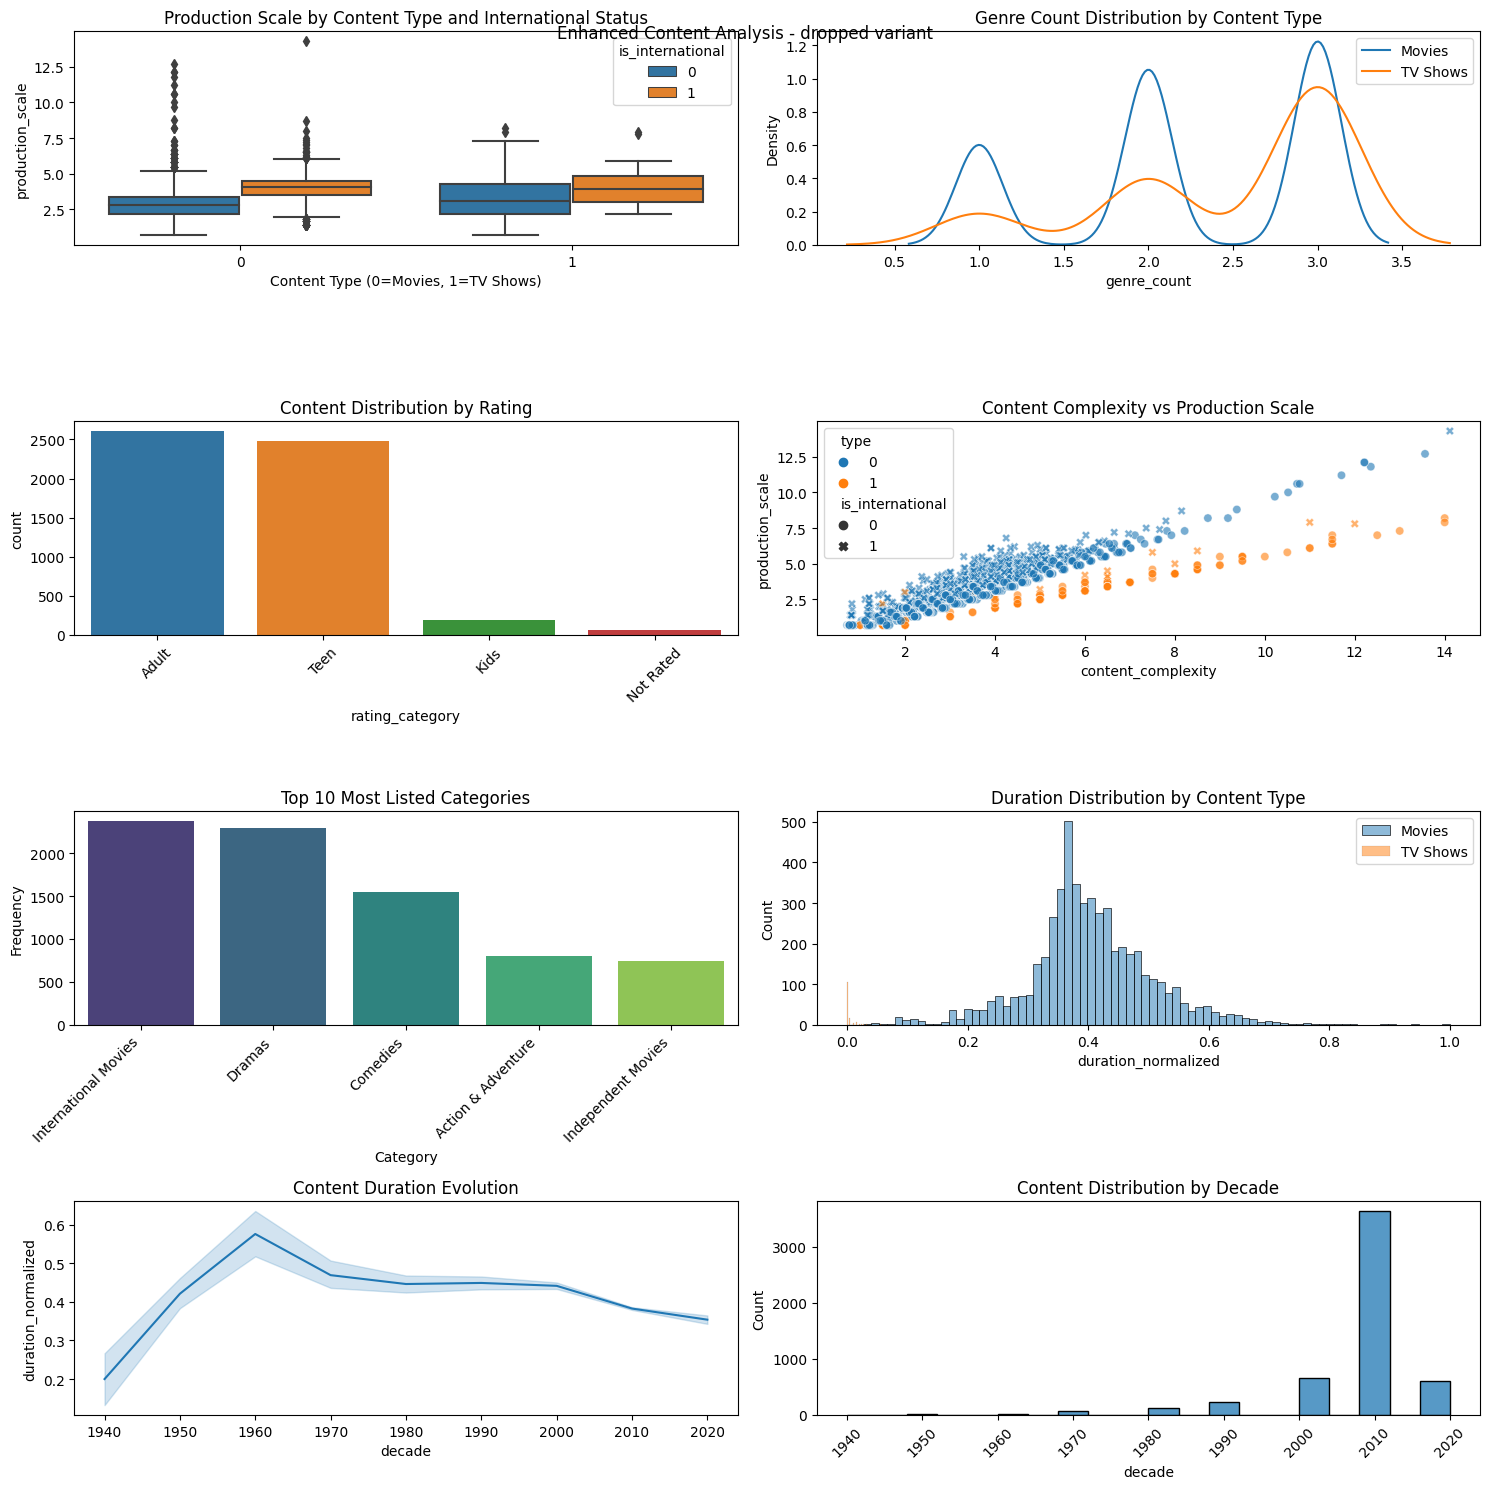


Summary Statistics by Content Type:

Movies:
       production_scale  content_complexity  genre_count  production_countries
count           5185.00             5185.00      5185.00               5185.00
mean               2.97                3.40         2.22                  1.29
std                1.25                1.25         0.77                  0.73
min                0.70                0.71         1.00                  1.00
25%                2.20                2.86         2.00                  1.00
50%                3.10                3.62         2.00                  1.00
75%                3.60                4.10         3.00                  1.00
max               14.30               14.12         3.00                  8.00

TV Shows:
       production_scale  content_complexity  genre_count  production_countries
count            147.00              147.00       147.00                147.00
mean               3.32                5.91         2.50                  

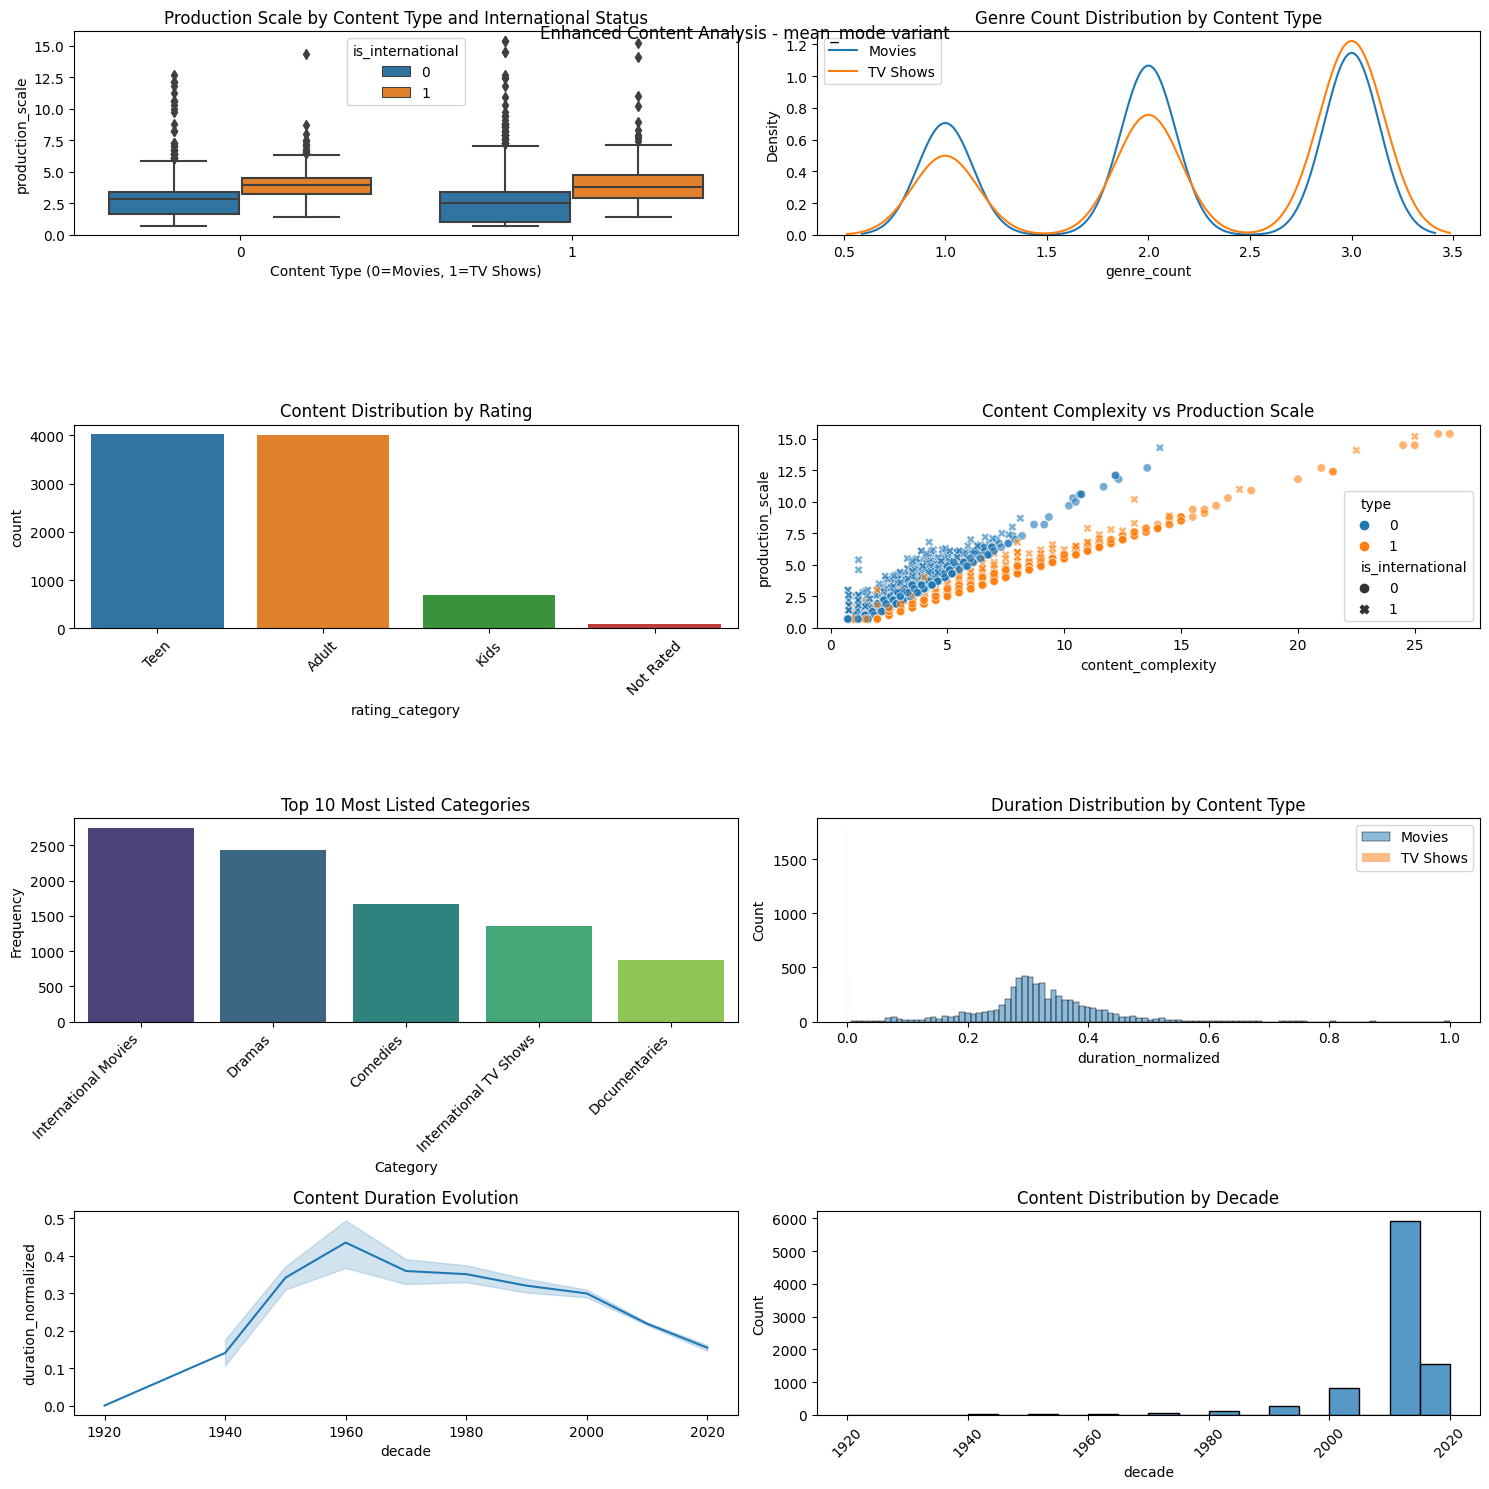


Summary Statistics by Content Type:

Movies:
       production_scale  content_complexity  genre_count  production_countries
count           6131.00             6131.00      6131.00               6131.00
mean               2.76                3.16         2.15                  1.28
std                1.34                1.37         0.78                  0.73
min                0.70                0.71         1.00                  1.00
25%                1.90                2.38         2.00                  1.00
50%                2.80                3.43         2.00                  1.00
75%                3.40                4.00         3.00                  1.00
max               14.30               14.09         3.00                 12.00

TV Shows:
       production_scale  content_complexity  genre_count  production_countries
count           2676.00             2676.00      2676.00               2676.00
mean               2.72                4.88         2.29                  

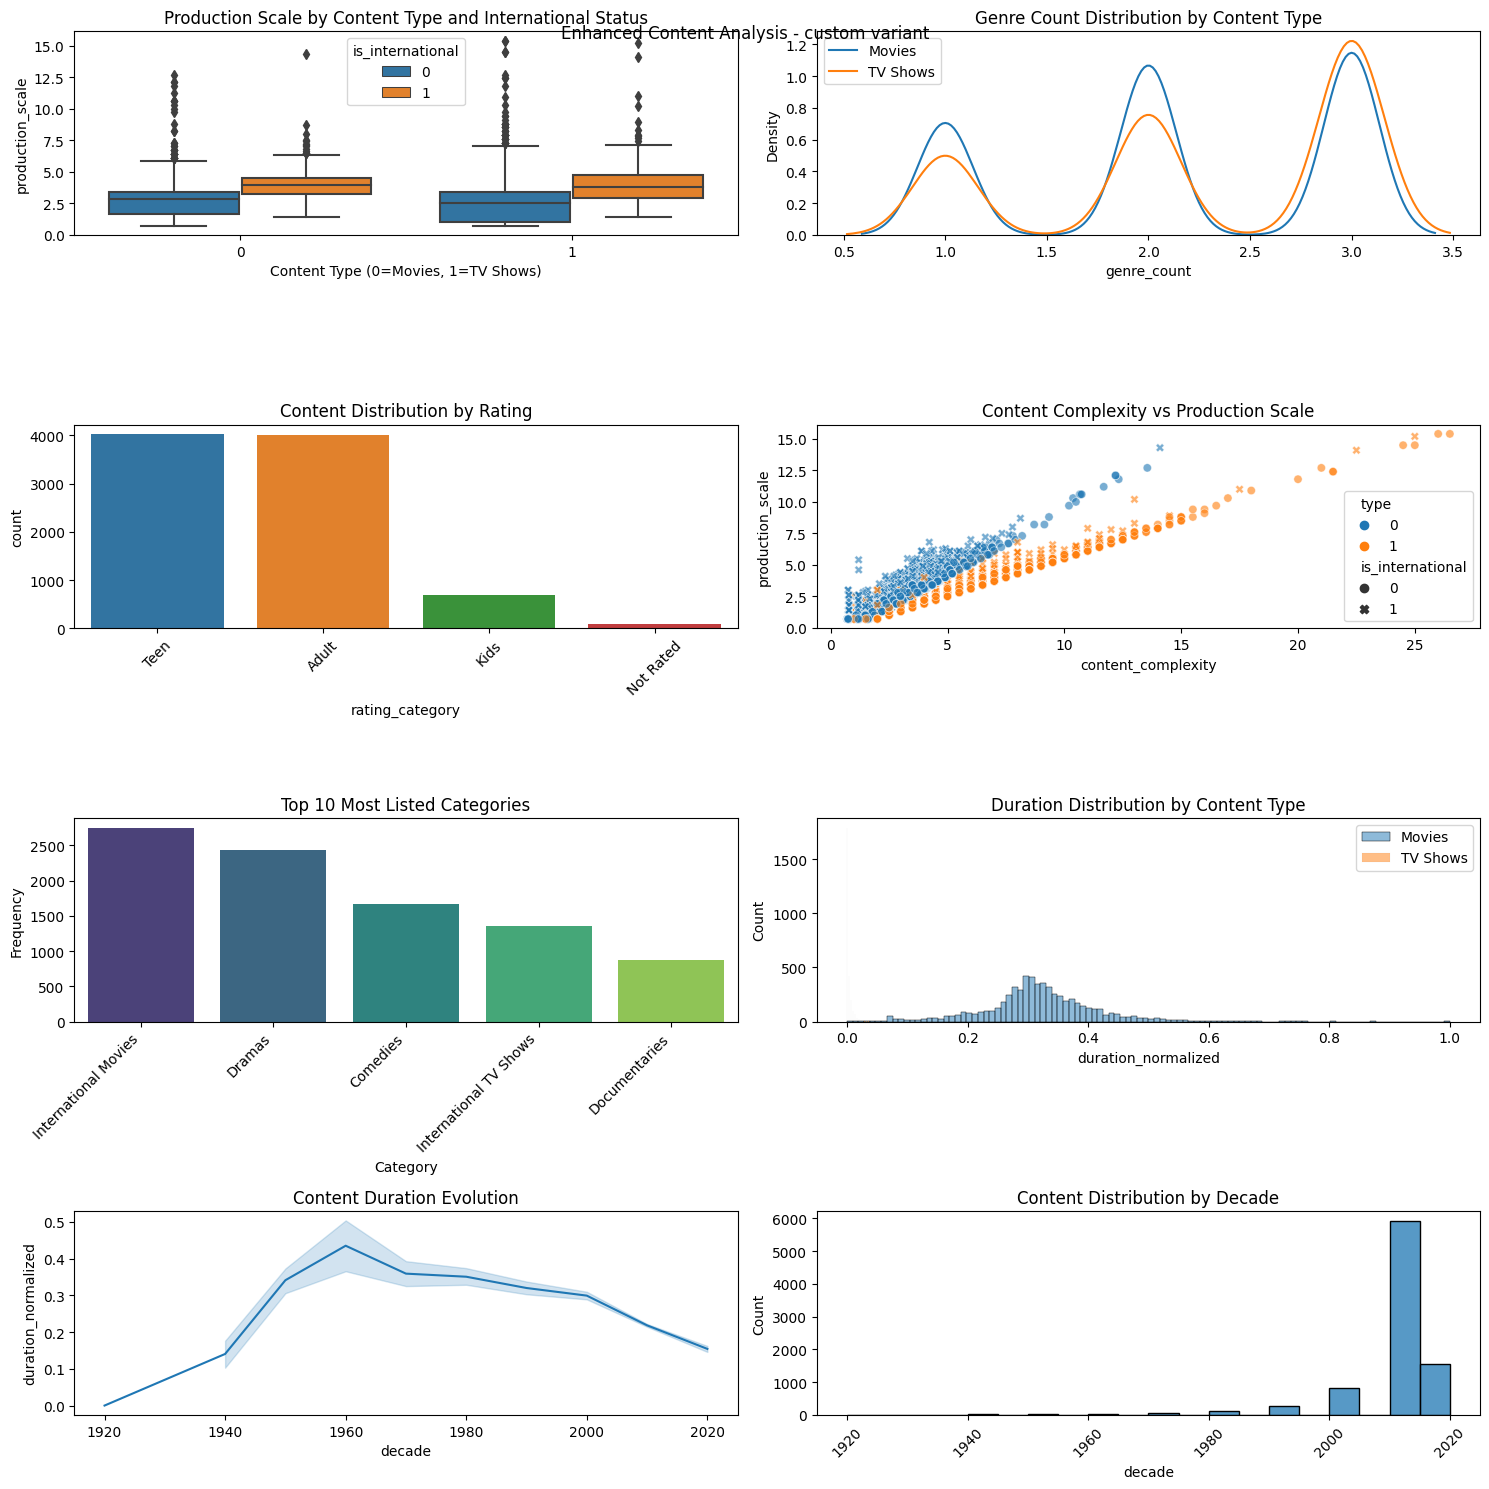


Summary Statistics by Content Type:

Movies:
       production_scale  content_complexity  genre_count  production_countries
count           6131.00             6131.00      6131.00               6131.00
mean               2.76                3.16         2.15                  1.28
std                1.34                1.37         0.78                  0.73
min                0.70                0.70         1.00                  1.00
25%                1.90                2.38         2.00                  1.00
50%                2.80                3.43         2.00                  1.00
75%                3.40                4.00         3.00                  1.00
max               14.30               14.09         3.00                 12.00

TV Shows:
       production_scale  content_complexity  genre_count  production_countries
count           2676.00             2676.00      2676.00               2676.00
mean               2.72                4.88         2.29                  

In [7]:
# New Operations Implementation
def enhance_features(df):
    """Enhanced feature engineering with new operations"""
    
    # 1. Separate analysis for Movies and TV Shows
    movies_mask = df['type'] == 0  # Assuming 0 is movies after encoding
    
    # 2. Production Scale Score
    df['production_scale'] = (
        df['production_countries'] * 0.4 +
        df['cast_size'] * 0.3 +
        df['is_international'].astype(int) * 0.3
    )
    
    # 3. Content Complexity Score - Separate for Movies and TV Shows
    df.loc[movies_mask, 'content_complexity'] = (
        df.loc[movies_mask, 'genre_count'] * 0.4 +
        df.loc[movies_mask, 'cast_size'] * 0.3 +
        df.loc[movies_mask, 'duration_normalized'] * 0.3
    )
    
    df.loc[~movies_mask, 'content_complexity'] = (
        df.loc[~movies_mask, 'genre_count'] * 0.5 +
        df.loc[~movies_mask, 'cast_size'] * 0.5
    )
    
    return df

def create_improved_visualizations(df):
    """Create separate visualizations for movies and TV shows"""
    movies_mask = df['type'] == 0
    
    # Create figure with subplots
    fig = plt.figure(figsize=(15, 15))
    
    # 1. Production Scale Analysis
    plt.subplot(4, 2, 1)
    sns.boxplot(data=df, x='type', y='production_scale', hue='is_international')
    plt.title('Production Scale by Content Type and International Status')
    plt.xlabel('Content Type (0=Movies, 1=TV Shows)')
    
    # 2. Genre Analysis - Separate by Type
    plt.subplot(4, 2, 2)
    for content_type, mask in [('Movies', movies_mask), ('TV Shows', ~movies_mask)]:
        sns.kdeplot(data=df[mask], x='genre_count', label=content_type)
    plt.legend()
    plt.title('Genre Count Distribution by Content Type')
    
    # 3. Rating Distribution with Production Countries
    plt.subplot(4, 2, 3)
    sns.countplot(data=df, x='rating_category')
    plt.title('Content Distribution by Rating')
    plt.xticks(rotation=45)
    
    # 4. Content Complexity
    plt.subplot(4, 2, 4)
    sns.scatterplot(data=df, x='content_complexity', y='production_scale', 
                    hue='type', style='is_international', alpha=0.6)
    plt.title('Content Complexity vs Production Scale')
    
    # 5. Top Genres Distribution
    categories = df['listed_in'].str.split(',').explode().str.strip()  
    top_10_categories = categories.value_counts().head(5)
    
    plt.subplot(4, 2, 5)
    sns.barplot(x=top_10_categories.index, y=top_10_categories.values, palette='viridis')
    
    plt.title('Top 10 Most Listed Categories')
    plt.xlabel('Category')
    plt.ylabel('Frequency')
    plt.xticks(rotation=45, ha='right')
        
    # 6. Duration Analysis by Type
    plt.subplot(4, 2, 6)
    for content_type, mask in [('Movies', movies_mask), ('TV Shows', ~movies_mask)]:
        sns.histplot(data=df[mask], x='duration_normalized', 
                    label=content_type, alpha=0.5)
    plt.legend()
    plt.title('Duration Distribution by Content Type')
    
    # 7. Content Evolution Over Time
    plt.subplot(4, 2, 7)
    sns.lineplot(data=df, x='decade', y='duration_normalized')
    plt.title('Content Duration Evolution')
     
    # 8. Temporal Distribution
    plt.subplot(4, 2, 8)
    sns.histplot(data=df, x='decade', bins=20)
    plt.title('Content Distribution by Decade')
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    return fig

# Apply new operations and create visualizations
for name, dataset in processed_variants.items():
    print(f"\nProcessing {name} variant:")
    
    # Apply new operations
    dataset = enhance_features(dataset)
    processed_variants[name] = dataset
    
    # Create and display new visualizations
    fig = create_improved_visualizations(dataset)
    plt.suptitle(f'Enhanced Content Analysis - {name} variant')
    plt.show()
    
    # Print summary statistics
    print("\nSummary Statistics by Content Type:")
    for content_type in [0, 1]:  # 0 for movies, 1 for TV shows
        mask = dataset['type'] == content_type
        type_name = 'Movies' if content_type == 0 else 'TV Shows'
        print(f"\n{type_name}:")
        print(dataset[mask][['production_scale', 'content_complexity', 
                           'genre_count', 'production_countries']].describe().round(2))

## 5. Feature Correlation Analysis

Before clustering, we inspect the correlation structure of the engineered feature set (excluding TF-IDF columns, which are handled separately by the vectoriser). High inter-feature correlation would indicate redundancy — features encoding the same signal that effectively double-counts a dimension in the Euclidean distance metric. Low-to-moderate correlations confirm that the engineered features span genuinely distinct dimensions of the content space.

We run this analysis across all three variants: if imputation has introduced systematic distortion in any feature's distribution, it will appear as an anomalous correlation pattern.


Analyzing dropped variant:


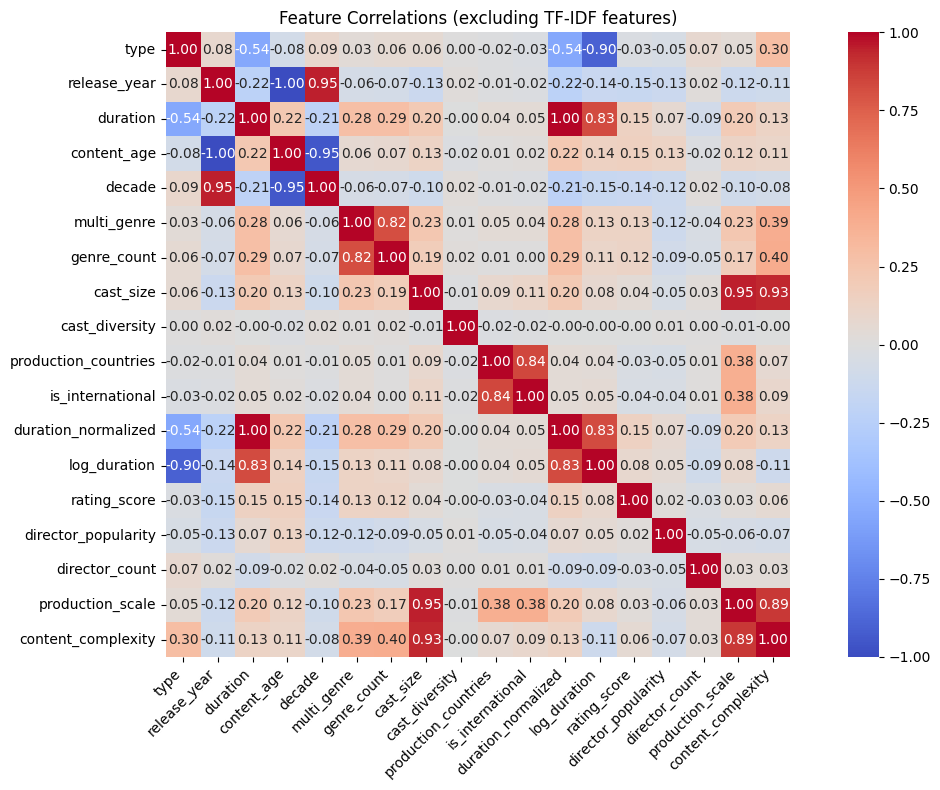


Analyzing mean_mode variant:


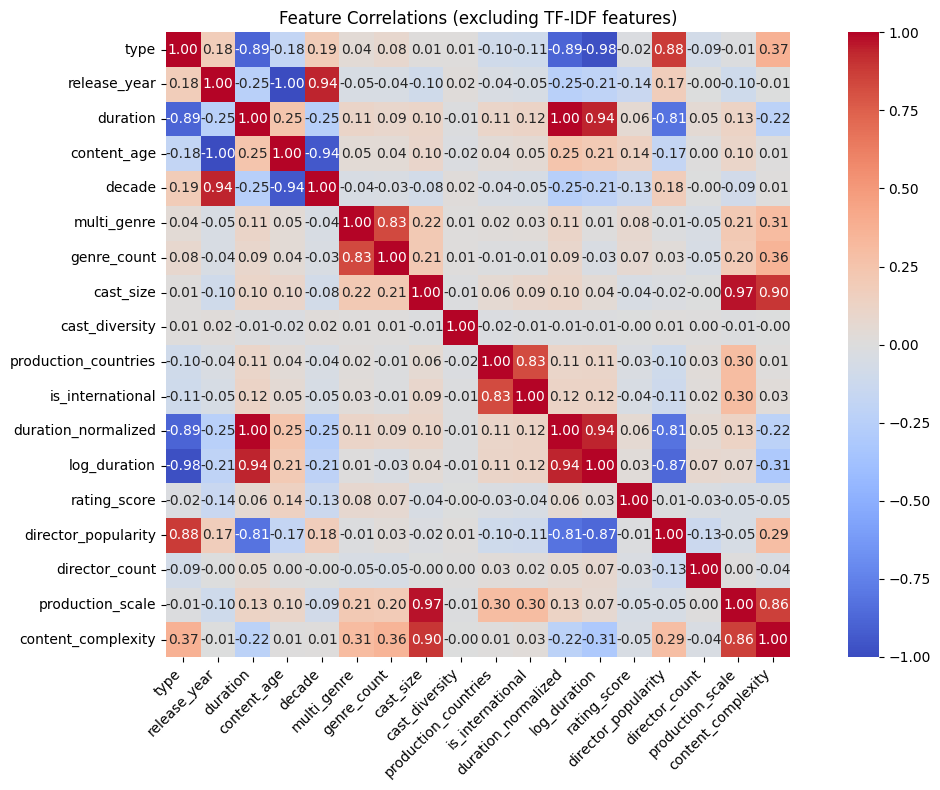


Analyzing custom variant:


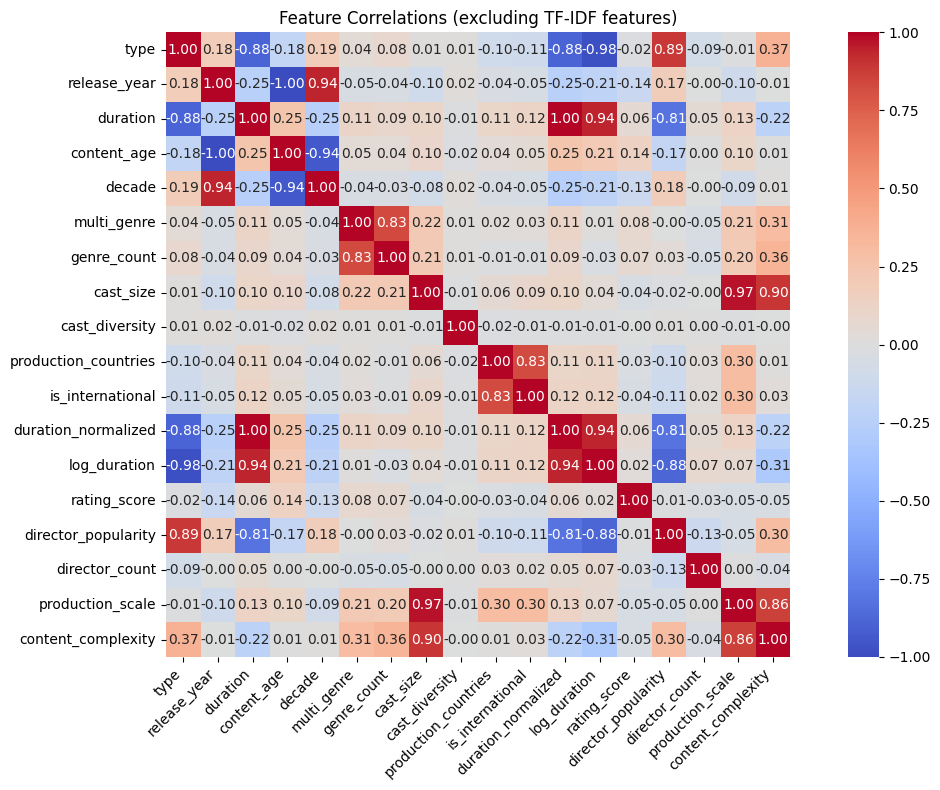

In [8]:

# Analyze feature correlations
def analyze_correlations(df):
    # Select numeric columns excluding TF-IDF features
    numeric_cols = [col for col in df.select_dtypes(include=['float64', 'int64']).columns 
                   if 'genre_feat' not in col]
    
    correlation_matrix = df[numeric_cols].corr()
    
    # Create correlation heatmap
    plt.figure(figsize=(12, 8))
    sns.heatmap(correlation_matrix, 
                cmap='coolwarm', 
                center=0, 
                annot=True,  
                fmt='.2f', 
                square=True)
    plt.title('Feature Correlations (excluding TF-IDF features)')
    
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    
    plt.tight_layout()
    return correlation_matrix

for name, dataset in processed_variants.items():
    print(f"\nAnalyzing {name} variant:")
    
    # Analyze correlations
    corr_matrix = analyze_correlations(dataset)
    plt.show()


**Observations:** `production_scale` and `cast_size` show expected positive correlation — larger productions naturally involve larger casts. `content_complexity` and `genre_count` are correlated by construction. Most other feature pairs show low correlation, confirming the feature set is non-redundant.

Critically, the correlation structure diverges across variants in the director-related features. Mean/mode imputation concentrates mass at the mode director, artificially inflating correlation between `director_popularity` and `director_count` for the imputed records. This pre-clustering divergence anticipates the differences in silhouette scores observed next.

## 6. Clustering

### 6.1 Feature Set

The features passed to K-Means are: `content_age`, `cast_diversity`, `content_complexity`, `production_scale`, `director_popularity`, and `director_count`. The high-dimensional TF-IDF genre features are available but excluded here to keep the distance metric interpretable — genre similarity is partially captured through `genre_count`, `multi_genre`, and `content_complexity`.

All selected features have been scaled during engineering. This is a prerequisite for K-Means: unscaled features with large numeric ranges (e.g. raw year values) would dominate Euclidean distance by magnitude alone, regardless of their actual discriminative value.

### 6.2 Selecting k

`k=4` was selected via elbow method analysis on inertia across k=2 to k=10. Four clusters provide a good tradeoff between silhouette score and interpretability: fewer clusters over-aggregate meaningfully different content types; more clusters produce groups that are difficult to interpret and may reflect dataset artefacts rather than genuine content structure.

dropped - Silhouette Score: 0.5403
mean_mode - Silhouette Score: 0.5058
custom - Silhouette Score: 0.4603


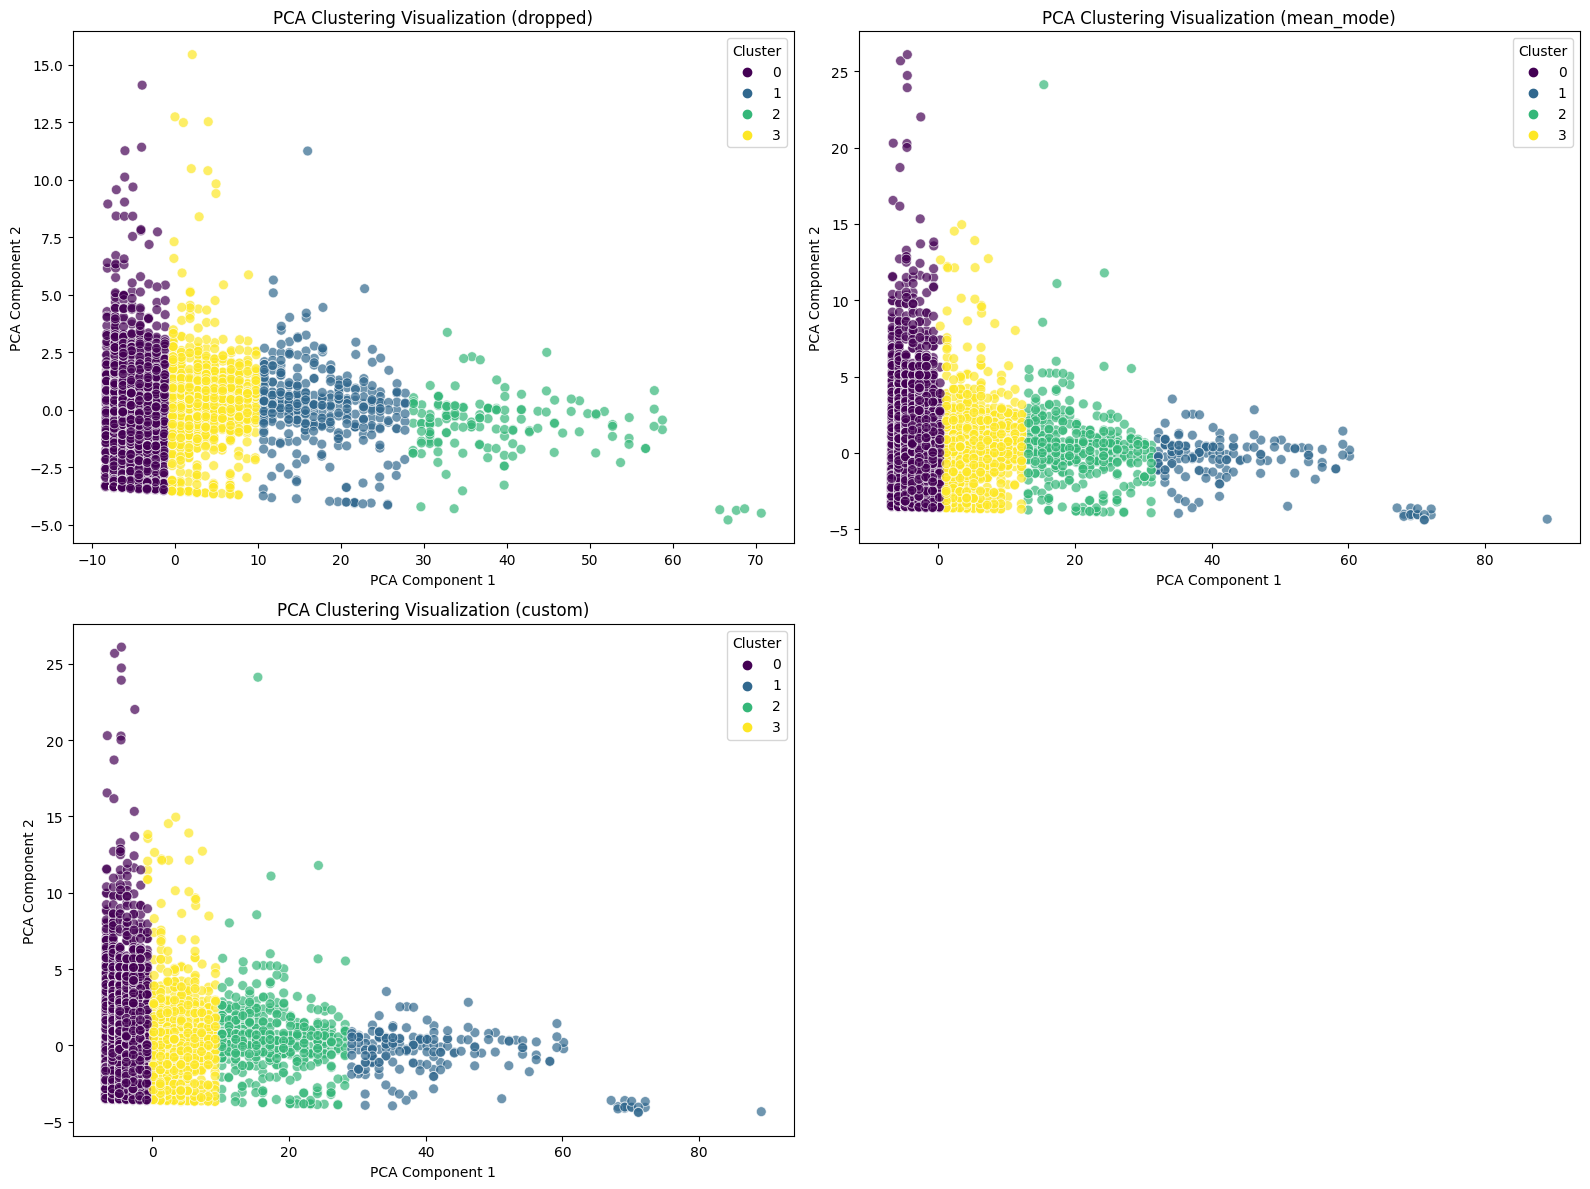

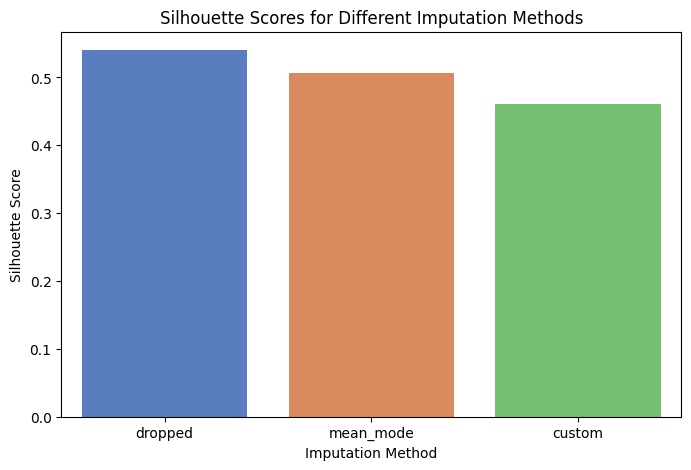

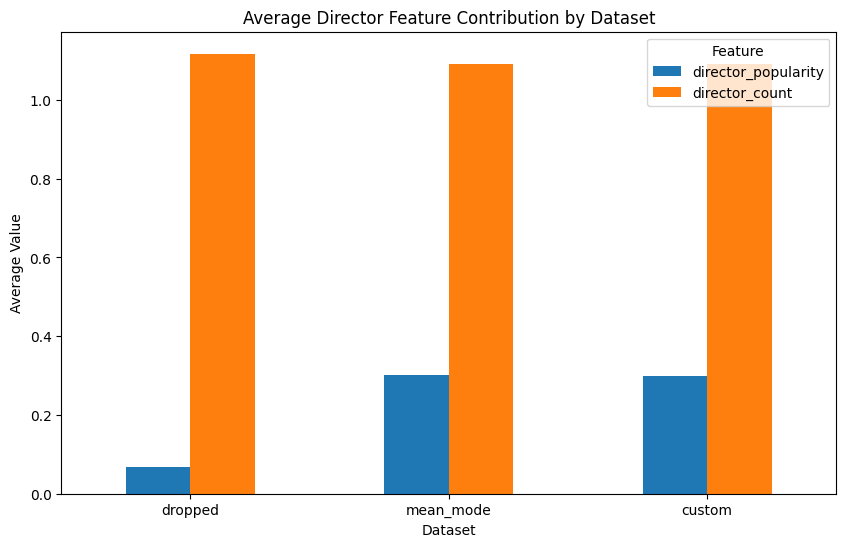

In [9]:
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

def perform_clustering_and_evaluate(datasets, features, n_clusters=4):
    cluster_results = {}
    silhouette_scores = {}

    for name, dataset in datasets.items():
        # Perform clustering
        kmeans = KMeans(n_clusters=n_clusters, random_state=42)
        labels = kmeans.fit_predict(dataset[features])
        cluster_results[name] = labels

        # Calculate silhouette score
        silhouette_scores[name] = silhouette_score(dataset[features], labels)

        print(f"{name} - Silhouette Score: {silhouette_scores[name]:.4f}")

    return cluster_results, silhouette_scores

def visualize_clustering_results(cluster_results, datasets, features):
    """
    Generate visualizations for clustering results across different imputation methods.

    Args:
        cluster_results (dict): Dictionary with clustering labels for each dataset variant.
        datasets (dict): Dictionary with processed datasets.
        features (list): List of features used for clustering.
    """
    pca = PCA(n_components=2)
    silhouette_scores = {}

    # PCA Visualization
    plt.figure(figsize=(16, 12))
    for i, (name, dataset) in enumerate(datasets.items()):
        X = dataset[features]
        pca_result = pca.fit_transform(X)
        labels = cluster_results[name]

        # PCA Scatter Plot
        plt.subplot(2, 2, i + 1)
        sns.scatterplot(
            x=pca_result[:, 0], y=pca_result[:, 1], 
            hue=labels, palette='viridis', s=50, alpha=0.7
        )
        plt.title(f'PCA Clustering Visualization ({name})')
        plt.xlabel('PCA Component 1')
        plt.ylabel('PCA Component 2')
        plt.legend(title='Cluster', loc='upper right')

    plt.tight_layout()
    plt.show()

    # Silhouette Scores Visualization
    silhouette_scores = {
        name: silhouette_score(datasets[name][features], cluster_results[name]) 
        for name in datasets.keys()
    }
    plt.figure(figsize=(8, 5))
    sns.barplot(x=list(silhouette_scores.keys()), y=list(silhouette_scores.values()), palette="muted")
    plt.title("Silhouette Scores for Different Imputation Methods")
    plt.ylabel("Silhouette Score")
    plt.xlabel("Imputation Method")
    plt.show()

    # Feature Contribution Visualization (example for director features)
    director_features = ['director_popularity', 'director_count']
    director_importance = {name: datasets[name][director_features].mean() for name in datasets.keys()}
    director_importance_df = pd.DataFrame(director_importance).T
    director_importance_df.plot(kind='bar', figsize=(10, 6))
    plt.title("Average Director Feature Contribution by Dataset")
    plt.ylabel("Average Value")
    plt.xlabel("Dataset")
    plt.xticks(rotation=0)
    plt.legend(title="Feature")
    plt.show()

features_for_clustering = ['content_age',
                           'cast_diversity',
                           'content_complexity',
                           'production_scale',
                           'director_popularity', 
                           'director_count']
cluster_results, silhouette_scores = perform_clustering_and_evaluate(processed_variants, features_for_clustering, n_clusters=4)
visualize_clustering_results(cluster_results, processed_variants, features_for_clustering)



## 7. Results and Discussion

### 7.1 Imputation Strategy Comparison

The silhouette scores across the three variants provide a direct, quantitative answer to the research question.

The **dropped variant** achieves the highest silhouette score. Despite losing ~30% of records, its clusters are more cohesive and better separated. The primary driver is director information: `director_popularity` is one of the more discriminative features in the set, and it is only fully intact in the dropped variant. Mean/mode and custom imputation introduce synthetic values for roughly 30% of records in this column, flattening the feature distribution and diluting the signal.

The **mean/mode and custom variants** produce similar scores to each other — which is informative in itself. It suggests that *whether* imputation occurred matters more than *which* strategy was used. Both methods introduce noise relative to the ground truth; the specific placeholder value is secondary.

### 7.2 Cluster Profiles

Based on centroid analysis of the dropped variant, the four clusters correspond broadly to:

- **Cluster 0 — High-scale international productions:** large cast, multiple production countries, high director popularity, diverse genres
- **Cluster 1 — Standard domestic content:** moderate production scale, single-country, mid-range complexity
- **Cluster 2 — Indie / limited-crew productions:** small casts, single or unknown director, lower production scale
- **Cluster 3 — Specialised audience content:** high genre specificity, strong rating category signal (Kids or Adult), atypical duration patterns

The PCA scatter plots confirm these groupings visually: the dropped variant produces more clearly separated point clouds than either imputed variant, where clusters overlap considerably in the 2D projection.

### 7.3 Methodological Conclusions

Three findings generalise beyond this specific dataset.

**Data quality outweighs sample size in unsupervised learning.** Unlike supervised learning, where additional examples improve generalisation against a fixed ground truth, unlabelled data that introduces artefactual structure actively harms clustering. K-Means will find structure in whatever the data presents — including structure induced by imputation. There is no label signal to regularise against.

**Missingness is not always ignorable.** Director information is more likely missing for lower-profile content, suggesting the data is MAR (Missing At Random) conditional on production scale — not MCAR. Dropping these records may therefore introduce selection bias toward well-documented mainstream productions. A rigorous follow-up would address this through multiple imputation or a formal sensitivity analysis.

**Feature engineering is the primary leverage point.** The quality of the clustering is almost entirely determined by the feature representation, not the algorithm. K-Means is a simple partitioning method applied here to a carefully constructed feature space. The same algorithm on raw, unengineered features would produce substantially weaker and less interpretable results.